# Architecture 2: BioClinicalBERT + TabNet — Training Notebook

**Model:** `emilyalsentzer/Bio_ClinicalBERT` (110M) + TabNet encoder → Fusion Head  
**Task:** 4-class ESI triage prediction (ESI 1–4)  
**Data:** `s3://ed-triage-capstone-group7/Data_Output/consolidated_dataset_features.csv`  
**Instance:** `ml.g4dn.xlarge` (T4 16GB) in SageMaker Studio

## Notebook Structure
1. Setup & installs
2. Load data from S3
3. Feature selection & train/val/test split
4. Dataset & DataLoader
5. Model definition (HybridBERTTabNet)
6. Training loop
7. Evaluation & results

## 1. Setup & Installs

In [44]:
# Install dependencies not pre-installed in the PyTorch SageMaker image
!pip install -q pytorch-tabnet transformers shap

In [45]:
import io
import pickle
import warnings
import numpy as np
import pandas as pd
import boto3
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from pytorch_tabnet.tab_network import TabNetNoEmbeddings
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
S3_BUCKET    = "ed-triage-capstone-group7"
DATA_KEY     = "Data_Output/consolidated_dataset_features.csv"
MODEL_KEY    = "models/arch2_bert_tabnet/"
BERT_MODEL   = "emilyalsentzer/Bio_ClinicalBERT"
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Load Data from S3

In [46]:
s3 = boto3.client("s3", region_name="us-east-1")

obj = s3.get_object(Bucket=S3_BUCKET, Key=DATA_KEY)
df  = pd.read_csv(io.BytesIO(obj["Body"].read()))

print(f"Loaded: {df.shape}")
print(f"\nTriage distribution:")
print(df['triage_encoded'].value_counts().sort_index().rename(
    {0: '0-Critical', 1: '1-Emergent', 2: '2-Urgent', 3: '3-LessUrgent'}
).to_string())

Loaded: (8383, 62)

Triage distribution:
triage_encoded
0-Critical       502
1-Emergent      3100
2-Urgent        4724
3-LessUrgent      57


## 3. Feature Selection & Train / Val / Test / Production Split

**Structured features (15):** scaled vitals (6) + derived flags (3) + demographics (6)

**4-way split:**
| Split | Size | Purpose |
|-------|------|---------|
| Train | 60% | Model training |
| Val | 15% | Early stopping, hyperparameter tuning |
| Test | 15% | Final reported evaluation metrics |
| Production | 10% | Held out for deployment / inference testing — never used during development |

All splits are stratified on triage level and saved to S3 immediately.

In [47]:
# ── Structured feature set (15 columns) ───────────────────────────────────────
VITALS_SCALED = ['temp_f_scaled', 'heart_rate_scaled', 'resp_rate_scaled',
                 'spo2_scaled', 'sbp_scaled', 'dbp_scaled']
VITAL_FLAGS   = ['spo2_abnormal', 'hr_tachycardia', 'hypotension']
df['race_other_combined'] = df[['race_hispanic', 'race_asian', 'race_other']].max(axis=1)
DEMOGRAPHICS  = ['age_scaled', 'gender_female',
                 'race_white', 'race_black', 'race_other_combined',
                 'transport_ordinal']

STRUCTURED_FEATURES = VITALS_SCALED + VITAL_FLAGS + DEMOGRAPHICS
print(f"Structured features ({len(STRUCTURED_FEATURES)}): {STRUCTURED_FEATURES}")
assert len(STRUCTURED_FEATURES) == 15

# ── Collapse ESI 4 (LessUrgent, class 3) into ESI 3 (Urgent, class 2) ─────────
# Class 3 has only 57 samples (0.7%) — too few to learn from or evaluate reliably.
# ESI 3 and 4 are clinically similar (non-urgent) and commonly merged in literature.
df['triage_3class'] = df['triage_encoded'].replace({3: 2})
print(f"\nOriginal 4-class distribution:")
print(df['triage_encoded'].value_counts().sort_index())
print(f"\n3-class distribution (ESI4 merged into ESI3):")
print(df['triage_3class'].value_counts().sort_index().rename(
    {0: '0-Critical', 1: '1-Emergent', 2: '2-Urgent/LessUrgent'}
))

NUM_CLASSES = 3
CLASS_WEIGHTS = torch.tensor([4.17, 0.68, 0.44], dtype=torch.float32)
print(f"\nClass weights: {CLASS_WEIGHTS.tolist()}")

# ── 3-way stratified split: 80 / 10 / 10 ─────────────────────────────────────
X = df[['combined_text', 'stay_id'] + STRUCTURED_FEATURES].copy()
y = df['triage_3class'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

total = len(X)
print(f"\nSplit sizes (n / % of total):")
print(f"  Train: {len(X_train):>4} ({len(X_train)/total*100:.0f}%)")
print(f"  Val:   {len(X_val):>4} ({len(X_val)/total*100:.0f}%)")
print(f"  Test:  {len(X_test):>4} ({len(X_test)/total*100:.0f}%)")

for name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(labels, return_counts=True)
    print(f"  {name} dist: {dict(zip(unique, counts))}")

# ── Save splits to S3 ──────────────────────────────────────────────────────────
def save_split_to_s3(X_split, y_split, key):
    split_df = X_split.copy()
    split_df['triage_encoded'] = y_split
    buf = io.BytesIO()
    split_df.to_csv(buf, index=False)
    buf.seek(0)
    s3.put_object(Bucket=S3_BUCKET, Key=key, Body=buf.getvalue(), ContentType="text/csv")
    print(f"  Saved → s3://{S3_BUCKET}/{key}  ({len(split_df)} rows)")

print("\nSaving splits to S3:")
save_split_to_s3(X_train, y_train, "Data_Output/splits/train_set.csv")
save_split_to_s3(X_val,   y_val,   "Data_Output/splits/val_set.csv")
save_split_to_s3(X_test,  y_test,  "Data_Output/splits/test_set.csv")
print("Done.")

Structured features (15): ['temp_f_scaled', 'heart_rate_scaled', 'resp_rate_scaled', 'spo2_scaled', 'sbp_scaled', 'dbp_scaled', 'spo2_abnormal', 'hr_tachycardia', 'hypotension', 'age_scaled', 'gender_female', 'race_white', 'race_black', 'race_other_combined', 'transport_ordinal']

Original 4-class distribution:
triage_encoded
0     502
1    3100
2    4724
3      57
Name: count, dtype: int64

3-class distribution (ESI4 merged into ESI3):
triage_3class
0-Critical              502
1-Emergent             3100
2-Urgent/LessUrgent    4781
Name: count, dtype: int64

Class weights: [4.170000076293945, 0.6800000071525574, 0.4399999976158142]

Split sizes (n / % of total):
  Train: 6706 (80%)
  Val:    838 (10%)
  Test:   839 (10%)
  Train dist: {np.int64(0): np.int64(402), np.int64(1): np.int64(2480), np.int64(2): np.int64(3824)}
  Val dist: {np.int64(0): np.int64(50), np.int64(1): np.int64(310), np.int64(2): np.int64(478)}
  Test dist: {np.int64(0): np.int64(50), np.int64(1): np.int64(310), np

## 4. Dataset & DataLoader

In [48]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
MAX_LEN   = 256  # 90th percentile of combined_text is ~200 words; 256 tokens covers >95%


class TriageDataset(Dataset):
    """
    Returns per sample:
      - input_ids, attention_mask  : BERT tokenized combined_text
      - structured                 : [15] float tensor of pre-scaled features
      - label                      : int (0-3)
    """
    def __init__(self, X: pd.DataFrame, y: np.ndarray, tokenizer, max_len: int):
        self.texts       = X['combined_text'].tolist()
        self.structured  = torch.tensor(
            X[STRUCTURED_FEATURES].values.astype(np.float32), dtype=torch.float32
        )
        self.labels      = torch.tensor(y, dtype=torch.long)
        self.tokenizer   = tokenizer
        self.max_len     = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'structured':     self.structured[idx],
            'label':          self.labels[idx]
        }


BATCH_SIZE = 64

train_dataset = TriageDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TriageDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TriageDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

# Sanity check
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  input_ids:      {batch['input_ids'].shape}")
print(f"  attention_mask: {batch['attention_mask'].shape}")
print(f"  structured:     {batch['structured'].shape}")
print(f"  label:          {batch['label'].shape}")

Train batches: 105 | Val batches: 14 | Test batches: 14

Batch shapes:
  input_ids:      torch.Size([64, 256])
  attention_mask: torch.Size([64, 256])
  structured:     torch.Size([64, 15])
  label:          torch.Size([64])


## 5. Model Definition

```
combined_text  →  BioClinicalBERT  →  [CLS] [B, 768]
                                                      →  concat [B, 832]  →  Fusion Head  →  [B, 4]
15 features    →  TabNet encoder   →       [B, 64]
```

In [49]:
class HybridBERTTabNet(nn.Module):
    def __init__(self, bert_model_name: str, num_structured: int = 15, num_classes: int = 3,
                 freeze_bert_layers: int = 10):
        super().__init__()

        # ── Text branch: BioClinicalBERT ──────────────────────────────────────
        self.bert = AutoModel.from_pretrained(bert_model_name)
        bert_dim  = self.bert.config.hidden_size  # 768

        # Freeze bottom N layers — only fine-tune top 2 + pooler
        modules_to_freeze = [self.bert.embeddings] + list(self.bert.encoder.layer[:freeze_bert_layers])
        for module in modules_to_freeze:
            for param in module.parameters():
                param.requires_grad = False

        # ── Structured branch: TabNetNoEmbeddings ─────────────────────────────
        TABNET_DIM = 64
        self.tabnet = TabNetNoEmbeddings(
            input_dim=num_structured,
            output_dim=TABNET_DIM,
            n_d=TABNET_DIM,
            n_a=TABNET_DIM,
            n_steps=5,
            gamma=1.5,
            n_independent=2,
            n_shared=2,
            virtual_batch_size=32,
            momentum=0.7,
            mask_type="sparsemax",
            epsilon=1e-15,
        )

        # ── Fusion head ───────────────────────────────────────────────────────
        fusion_dim = bert_dim + TABNET_DIM  # 768 + 64 = 832
        self.fusion = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def to(self, device):
        super().to(device)
        self.tabnet.encoder.group_attention_matrix = \
            self.tabnet.encoder.group_attention_matrix.to(device)
        return self

    def forward(self, input_ids, attention_mask, structured):
        bert_out      = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = bert_out.last_hidden_state[:, 0, :]  # [B, 768]

        tabnet_embedding, M_loss = self.tabnet(structured)   # [B, 64]

        combined = torch.cat([cls_embedding, tabnet_embedding], dim=1)  # [B, 832]
        logits   = self.fusion(combined)                                 # [B, 3]

        return logits, M_loss


model = HybridBERTTabNet(BERT_MODEL, num_classes=NUM_CLASSES, freeze_bert_layers=10).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

with torch.no_grad():
    b = next(iter(train_loader))
    logits, _ = model(
        b['input_ids'].to(DEVICE),
        b['attention_mask'].to(DEVICE),
        b['structured'].to(DEVICE)
    )
    print(f"\nForward pass OK — logits shape: {logits.shape}")

Total parameters:     108,977,173
Trainable parameters: 15,433,237
Frozen parameters:    93,543,936

Forward pass OK — logits shape: torch.Size([64, 3])


## 6. Training Loop

**Optimizer:** AdamW with two LR groups — BERT at `2e-5`, TabNet+fusion at `1e-3`  
**Schedule:** Cosine warmup (500 steps)  
**Loss:** Class-weighted CrossEntropy + TabNet sparsity regularization (`lambda_sparse=1e-3`)  
**Early stopping:** patience=5 on validation macro-F1

In [50]:
# ── Optimizer: two LR groups ───────────────────────────────────────────────────
bert_params   = list(model.bert.parameters())
other_params  = list(model.tabnet.parameters()) + list(model.fusion.parameters())

optimizer = AdamW([
    {'params': bert_params,  'lr': 5e-6, 'weight_decay': 0.01},
    {'params': other_params, 'lr': 1e-3, 'weight_decay': 1e-5},
])

# ── LR schedule: cosine with linear warmup ────────────────────────────────────
NUM_EPOCHS    = 20
total_steps   = len(train_loader) * NUM_EPOCHS
WARMUP_STEPS  = max(1, int(0.06 * total_steps))
scheduler     = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps
)

# ── Loss: use CLASS_WEIGHTS defined in split cell (3 classes) ─────────────────
LAMBDA_SPARSE = 1e-3
criterion     = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE))

# ── Mixed precision scaler ────────────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {WARMUP_STEPS}")
print(f"Class weights: {CLASS_WEIGHTS.tolist()}")

Total training steps: 2100
Warmup steps: 126
Class weights: [4.170000076293945, 0.6800000071525574, 0.4399999976158142]


In [51]:
def run_epoch(model, loader, optimizer, criterion, scheduler, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        structured     = batch['structured'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits, M_loss = model(input_ids, attention_mask, structured)
            ce_loss   = criterion(logits, labels)
            loss      = ce_loss + LAMBDA_SPARSE * M_loss

        if train:
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss   = total_loss / len(loader)
    macro_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1, all_preds, all_labels


# ── Training loop with early stopping (patience=8) ────────────────────────────
PATIENCE          = 8
best_val_f1       = 0.0
patience_counter  = 0
history           = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

print(f"Training on {DEVICE} for up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})\n")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1, _, _ = run_epoch(
        model, train_loader, optimizer, criterion, scheduler, scaler, train=True
    )
    with torch.no_grad():
        val_loss, val_f1, _, _ = run_epoch(
            model, val_loader, optimizer, criterion, scheduler, scaler, train=False
        )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    improved = val_f1 > best_val_f1
    if improved:
        best_val_f1      = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), "/tmp/best_model.pt")
    else:
        patience_counter += 1

    marker = " ← best" if improved else f" (patience {patience_counter}/{PATIENCE})"
    print(f"Epoch {epoch:02d} | "
          f"train_loss={train_loss:.4f} train_f1={train_f1:.4f} | "
          f"val_loss={val_loss:.4f} val_f1={val_f1:.4f}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest val macro-F1: {best_val_f1:.4f}")

Training on cuda for up to 20 epochs (early stopping patience=8)

Epoch 01 | train_loss=1.0823 train_f1=0.3647 | val_loss=1.0365 val_f1=0.4289 ← best
Epoch 02 | train_loss=1.0308 train_f1=0.4222 | val_loss=0.9206 val_f1=0.4540 ← best
Epoch 03 | train_loss=0.9666 train_f1=0.4608 | val_loss=0.8940 val_f1=0.4256 (patience 1/8)
Epoch 04 | train_loss=0.9554 train_f1=0.4712 | val_loss=0.9855 val_f1=0.5121 ← best
Epoch 05 | train_loss=0.9286 train_f1=0.4795 | val_loss=0.8703 val_f1=0.5171 ← best
Epoch 06 | train_loss=0.8814 train_f1=0.4912 | val_loss=0.8310 val_f1=0.5179 ← best
Epoch 07 | train_loss=0.8741 train_f1=0.5093 | val_loss=0.8552 val_f1=0.4918 (patience 1/8)
Epoch 08 | train_loss=0.8412 train_f1=0.5224 | val_loss=0.8154 val_f1=0.5112 (patience 2/8)
Epoch 09 | train_loss=0.8265 train_f1=0.5202 | val_loss=0.8109 val_f1=0.5689 ← best
Epoch 10 | train_loss=0.8027 train_f1=0.5431 | val_loss=0.8153 val_f1=0.5167 (patience 1/8)
Epoch 11 | train_loss=0.7982 train_f1=0.5425 | val_loss=0.8197

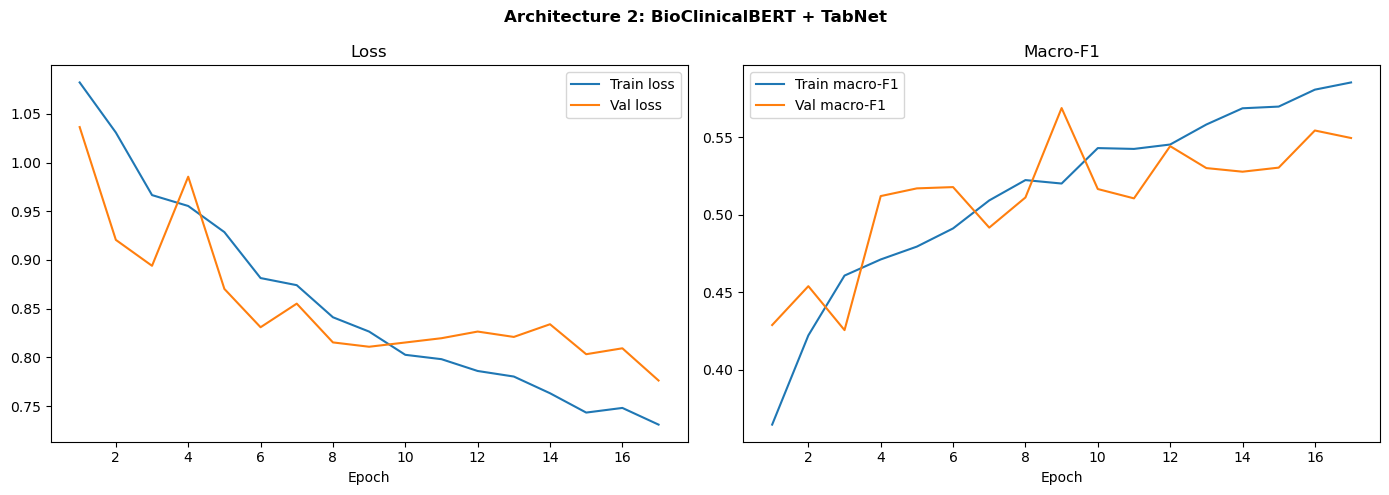

In [52]:
# ── Training curves ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_run = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_run, history['train_loss'], label='Train loss')
ax1.plot(epochs_run, history['val_loss'],   label='Val loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs_run, history['train_f1'], label='Train macro-F1')
ax2.plot(epochs_run, history['val_f1'],   label='Val macro-F1')
ax2.set_title('Macro-F1')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.suptitle('Architecture 2: BioClinicalBERT + TabNet', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Evaluation on Test Set

In [53]:
# Load best checkpoint
model.load_state_dict(torch.load("/tmp/best_model.pt", map_location=DEVICE))
model.eval()

with torch.no_grad():
    test_loss, test_f1, test_preds, test_labels = run_epoch(
        model, test_loader, optimizer, criterion, scheduler, scaler, train=False
    )

print(f"Test loss:     {test_loss:.4f}")
print(f"Test macro-F1: {test_f1:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=['L1-Critical', 'L2-Emergent', 'L3-Urgent/LessUrgent'],
    zero_division=0
))

Test loss:     0.8844
Test macro-F1: 0.5394

                      precision    recall  f1-score   support

         L1-Critical       0.20      0.48      0.28        50
         L2-Emergent       0.59      0.56      0.58       310
L3-Urgent/LessUrgent       0.81      0.72      0.76       479

            accuracy                           0.64       839
           macro avg       0.53      0.59      0.54       839
        weighted avg       0.69      0.64      0.66       839



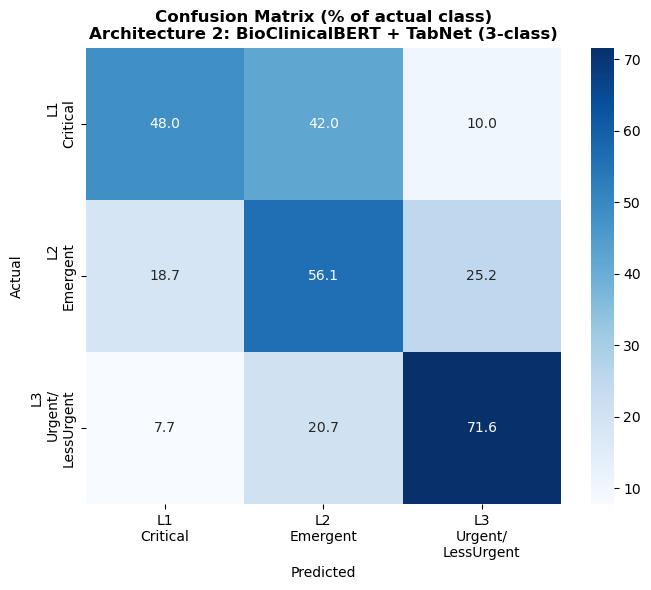

In [54]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm     = confusion_matrix(test_labels, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels = ['L1\nCritical', 'L2\nEmergent', 'L3\nUrgent/\nLessUrgent']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (% of actual class)\nArchitecture 2: BioClinicalBERT + TabNet (3-class)',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
# ── Save model to S3 ──────────────────────────────────────────────────────────
# Save model weights
torch.save(model.state_dict(), "/tmp/arch2_final.pt")
s3.upload_file("/tmp/arch2_final.pt", S3_BUCKET, MODEL_KEY + "arch2_final.pt")
print(f"Model saved → s3://{S3_BUCKET}/{MODEL_KEY}arch2_final.pt")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv("/tmp/training_history.csv", index=False)
s3.upload_file("/tmp/training_history.csv", S3_BUCKET, MODEL_KEY + "training_history.csv")
print(f"History saved → s3://{S3_BUCKET}/{MODEL_KEY}training_history.csv")

Model saved → s3://ed-triage-capstone-group7/models/arch2_bert_tabnet/arch2_final.pt
History saved → s3://ed-triage-capstone-group7/models/arch2_bert_tabnet/training_history.csv
